In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 18.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 39.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      /tmp/pip-build-env-cos08htb/overlay/lib/python3.10/site-packages/setuptools/dist.py:332: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      /tmp/pip-build-env-cos08htb/overlay/lib/python3.10/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers ar

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import logging
from torch import cuda
from transformers import AutoTokenizer, AutoModel

logging.basicConfig(level=logging.ERROR)

# Select device
device = 'cuda' if cuda.is_available() else 'cpu'


In [ ]:

from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:
import pandas as pd

dataset_path = "/kaggle/input/education-msc-updated/Education column updated data.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,Combined,Education
0,"Name: Masum Rahman, Job_Title: Software Engine...",5
1,"Name: Majbah Uddin, Job_Title: Software Engine...",5
2,"Name: Najmul Hoq, Job_Title: JavaScript || PHP...",5
3,"Name: Robin Halder, Job_Title: Software Engine...",5
4,"Name: Masum Rahman, Job_Title: Software Engine...",5


In [ ]:
# Create the labels based on Skills score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['Education_Label'] = df['Education'].apply(map_labels)

print("Mapped Education_Label:")
print(df['Education_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/Education_Label.csv', index=False)


Mapped Education_Label:
Education_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  Education  \
0  Name: Masum Rahman, Job_Title: Software Engine...          5   
1  Name: Majbah Uddin, Job_Title: Software Engine...          5   
2  Name: Najmul Hoq, Job_Title: JavaScript || PHP...          5   
3  Name: Robin Halder, Job_Title: Software Engine...          5   
4  Name: Masum Rahman, Job_Title: Software Engine...          5   

   Education_Label  
0                2  
1                2  
2                2  
3                2  
4                2  


In [ ]:

from transformers import AutoTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the tokenizer
tokenizer = RobertaTokenizer.from_pretrained("Peraboom/LastBERT")

df = pd.read_csv("/kaggle/working/Education_Label.csv")



# Function to tokenize the text using RoBERTa tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'Education_Label']].head())


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0    [input_ids, attention_mask]
1    [input_ids, attention_mask]
2    [input_ids, attention_mask]
3    [input_ids, attention_mask]
4    [input_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Education_Label
0  Name: Masum Rahman, Job_Title: Software Engine...                2
1  Name: Majbah Uddin, Job_Title: Software Engine...                2
2  Name: Najmul Hoq, Job_Title: JavaScript || PHP...                2
3  Name: Robin Halder, Job_Title: Software Engine...                2
4  Name: Masum Rahman, Job_Title: Software Engine...                2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/Education_Label.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")


output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print(f"Files saved to {output_dir}:")
print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
Files saved to /kaggle/working/:
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# Load LastBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

# Define the custom PyTorch Dataset
class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the combined text and label for a specific index
        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Education_Label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check a batch from the train DataLoader
for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break  # Just to check one batch only


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Input IDs: tensor([[ 101, 2171, 1024,  ..., 5482, 1006,  102],
        [ 101, 2171, 1024,  ...,    0,    0,    0],
        [ 101, 2171, 1024,  ..., 1010, 5107,  102],
        ...,
        [ 101, 2171, 1024,  ...,    0,    0,    0],
        [ 101, 2171, 1024,  ..., 2099, 7705,  102],
        [ 101, 2171, 1024,  ...,    0,    0,    0]])
Attention Mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([0, 0, 1, 1, 1, 2, 1, 1, 2, 0, 2, 1, 2, 2, 1, 2])


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification

# Define the LastBERT-based model
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()

        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True  # Fixes classifier size mismatch
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Forward pass through LastBERT
        output = self.lastbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        return output.logits

# Initialize the model
model = LastBERTClass(num_labels=3)  # Negative (0), Neutral (1), Positive (2)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Print model summary
print(model)


config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LastBERTClass(
  (lastbert): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 384, padding_idx=0)
        (position_embeddings): Embedding(512, 384)
        (token_type_embeddings): Embedding(2, 384)
        (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-5): 6 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=384, out_features=

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW  # Correct import
from sklearn.model_selection import train_test_split

# Define the custom Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare data
texts = df['Combined'].tolist()
labels = df['Education_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("Peraboom/LastBERT")

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

# Dataloaders
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# Define the LastBERT model class
class LastBERTClass(nn.Module):
    def __init__(self, num_labels=3):
        super(LastBERTClass, self).__init__()
        self.lastbert = AutoModelForSequenceClassification.from_pretrained(
            "Peraboom/LastBERT",
            num_labels=num_labels,
            ignore_mismatched_sizes=True
        )

    def forward(self, input_ids, attention_mask):
        output = self.lastbert(input_ids=input_ids, attention_mask=attention_mask)
        return output.logits

# Initialize model
model = LastBERTClass(num_labels=3)

# Multi-GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)

# Training loop
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=10):
    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs

                loss = criterion(logits, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# Train model
train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, epochs=15)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Peraboom/LastBERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 384]) in the checkpoint and torch.Size([3, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Epoch 1/15
Training Loss: 1.1006, Training Accuracy: 0.3408
Validation Loss: 1.0947, Validation Accuracy: 0.3321
Epoch 2/15
Training Loss: 1.0925, Training Accuracy: 0.3848
Validation Loss: 1.0887, Validation Accuracy: 0.5047
Epoch 3/15
Training Loss: 1.0874, Training Accuracy: 0.4263
Validation Loss: 1.0819, Validation Accuracy: 0.6588
Epoch 4/15
Training Loss: 1.0808, Training Accuracy: 0.4737
Validation Loss: 1.0734, Validation Accuracy: 0.6746
Epoch 5/15
Training Loss: 1.0708, Training Accuracy: 0.5413
Validation Loss: 1.0622, Validation Accuracy: 0.7542
Epoch 6/15
Training Loss: 1.0579, Training Accuracy: 0.5958
Validation Loss: 1.0466, Validation Accuracy: 0.7596
Epoch 7/15
Training Loss: 1.0407, Training Accuracy: 0.6365
Validation Loss: 1.0233, Validation Accuracy: 0.7628
Epoch 8/15
Training Loss: 1.0143, Training Accuracy: 0.6734
Validation Loss: 0.9876, Validation Accuracy: 0.7777
Epoch 9/15
Training Loss: 0.9721, Training Accuracy: 0.7098
Validation Loss: 0.9299, Validation 

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='lastbert_model.pth', tokenizer_path='lastbert_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to lastbert_model.pth
Tokenizer saved to lastbert_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss, roc_auc_score
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       727
     Class 1       0.94      0.85      0.89       751
     Class 2       0.86      0.94      0.90       735

    accuracy                           0.93      2213
   macro avg       0.93      0.93      0.93      2213
weighted avg       0.93      0.93      0.93      2213

Hamming Loss: 0.0705


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


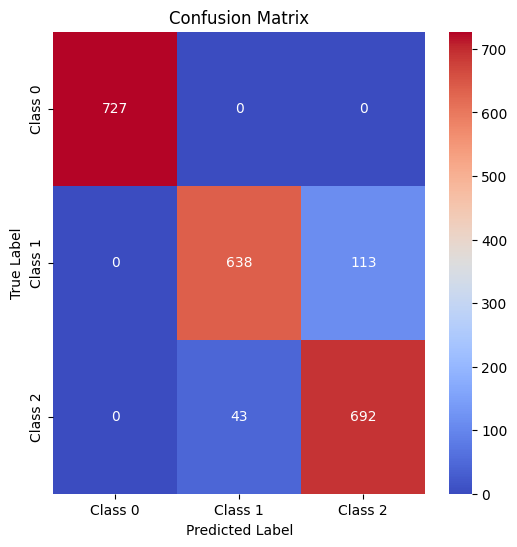

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs  # Logits are returned directly

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm)

# Plotting Confusion Matrix with different color
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=True,
                xticklabels=["Class 0","Class 1", "Class 2"],
                yticklabels=["Class 0","Class 1", "Class 2"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Call the evaluate_model function to evaluate the model
evaluate_model(model, val_dataloader, device)


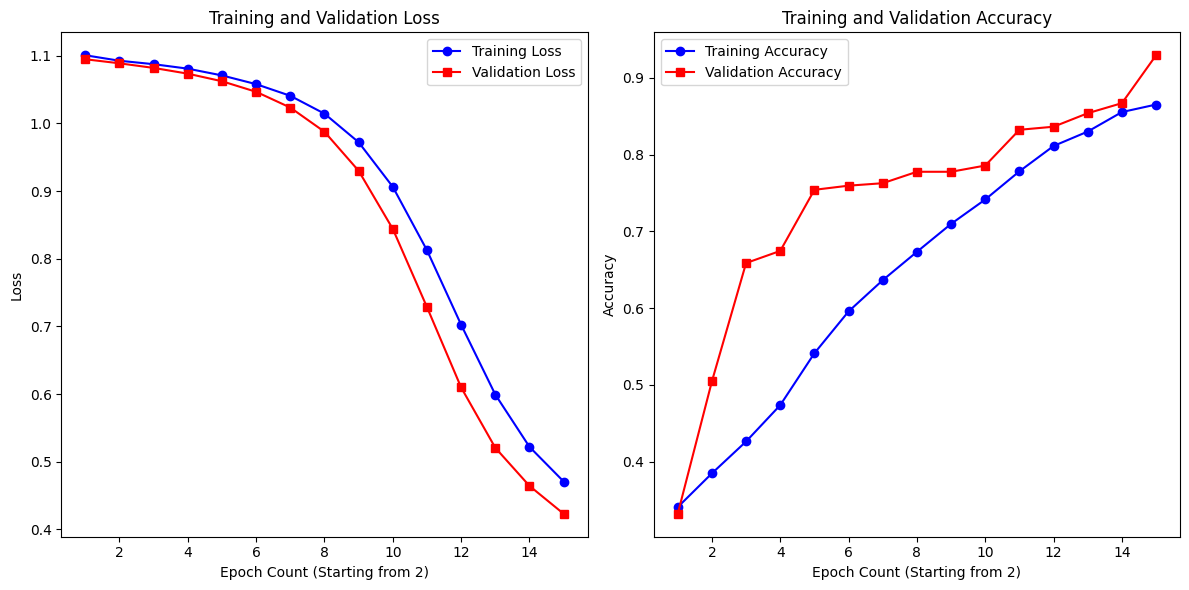

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 16))

train_loss = [
    1.1006, 1.0925, 1.0874, 1.0808, 1.0708, 1.0579, 1.0407, 1.0143, 0.9721,
    0.9062, 0.8125, 0.7024, 0.5993, 0.5221, 0.4709
]

val_loss = [
    1.0947, 1.0887, 1.0819, 1.0734, 1.0622, 1.0466, 1.0233, 0.9876, 0.9299,
    0.8440, 0.7285, 0.6098, 0.5207, 0.4644, 0.4232
]

train_accuracy = [
    0.3408, 0.3848, 0.4263, 0.4737, 0.5413, 0.5958, 0.6365, 0.6734, 0.7098,
    0.7416, 0.7783, 0.8113, 0.8301, 0.8555, 0.8653
]

val_accuracy = [
    0.3321, 0.5047, 0.6588, 0.6746, 0.7542, 0.7596, 0.7628, 0.7777, 0.7777,
    0.7858, 0.8324, 0.8364, 0.8540, 0.8671, 0.9295
]



# Plotting loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'o-', label='Training Loss', color='blue')
plt.plot(epochs, val_loss, 's-', label='Validation Loss', color='red')
plt.xlabel('Epoch Count (Starting from 2)')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plotting accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, 'o-', label='Training Accuracy', color='blue')
plt.plot(epochs, val_accuracy, 's-', label='Validation Accuracy', color='red')
plt.xlabel('Epoch Count (Starting from 2)')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()


plt.tight_layout()
plt.show()
